In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (r2_score, mean_absolute_error,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             RocCurveDisplay, average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

In [ ]:
from google.colab import files
uploaded=files.upload('sample_data_1')

Saving sample_data_1.xlsx to sample_data_1/sample_data_1.xlsx


In [ ]:
weld_data=pd.read_excel('sample_data_1/sample_data_1.xlsx')

In [ ]:
weld_data

,block,power (W),welding speed (m/min),gas flow rate (l/min),focal position (mm),angular position (°),material strenght steel (mm),weldnumber,position on the weld path (mm),cracking in the weld metal (yes/no),weld width steel (µm),weld width copper (µm),weld depth copper (µm),gap (µm),Unnamed: 14,Unnamed: 15
0,1,1050,1.0,15,0,0,0.6,1,8,no,2097.0,286.0,110.0,58.0,NaN,NaN
1,1,1050,1.0,15,0,0,0.6,1,16,no,2069.0,384.0,149.0,85.0,NaN,NaN
2,1,1050,1.0,15,0,0,0.6,1,24,no,2043.0,385.0,177.0,91.0,NaN,NaN
3,1,1050,1.0,15,0,0,0.6,1,32,no,2010.0,414.0,164.0,58.0,NaN,NaN
4,1,1050,1.0,15,0,0,0.6,2,8,no,2232.0,320.0,149.0,102.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2,1200,1.2,20,-2,15,0.5,4,32,yes,1645.0,484.0,454.0,17.0,3.0,288.57
356,2,1200,1.2,20,-2,15,0.5,5,8,no,2035.0,151.0,14.0,33.0,NaN,NaN
357,2,1200,1.2,20,-2,15,0.5,5,16,no,2007.0,109.0,12.0,31.0,NaN,NaN
358,2,1200,1.2,20,-2,15,0.5,5,24,no,1915.0,61.0,9.0,21.0,NaN,NaN


In [ ]:
weld_data_1 = weld_data.drop(['block','weldnumber','Unnamed: 14','Unnamed: 15'], axis=1)
weld_data_1['cracking in the weld metal (yes/no)'] = (
    weld_data_1['cracking in the weld metal (yes/no)'].map({'no': 0, 'yes': 1})
)


In [ ]:
def engineer_features(df):
    df = df.copy()
    df['heat_input']       = df['power (W)'] / df['welding speed (m/min)']
    df['heat_input_sq']    = df['heat_input'] ** 2
    df['speed_sq']         = df['welding speed (m/min)'] ** 2
    df['focal_abs']        = abs(df['focal position (mm)'])
    df['heat_x_angular']   = df['heat_input'] * abs(df['angular position (°)'])
    df['gas_x_heat']       = df['gas flow rate (l/min)'] * df['heat_input']
    df['heat_x_material']  = df['heat_input'] * df['material strenght steel (mm)']
    df['power_x_material'] = df['power (W)'] * df['material strenght steel (mm)']
    return df

weld_data_1 = engineer_features(weld_data_1)

FEATURES = [
    'power (W)', 'welding speed (m/min)', 'gas flow rate (l/min)',
    'focal position (mm)', 'angular position (°)',
    'material strenght steel (mm)', 'position on the weld path (mm)',
    'heat_input', 'heat_input_sq', 'speed_sq', 'focal_abs',
    'heat_x_angular', 'gas_x_heat', 'heat_x_material', 'power_x_material'
]

REGRESSION_TARGETS = [
    'weld width steel (µm)',
    'weld width copper (µm)',
    'weld depth copper (µm)',
    'gap (µm)'
]

CRACK_TARGET = 'cracking in the weld metal (yes/no)'
CRACK_THRESHOLD = 0.4

REGRESSION RESULTS

  weld width steel (µm)
    R²  : 0.5248
    MAE : 120.77 µm


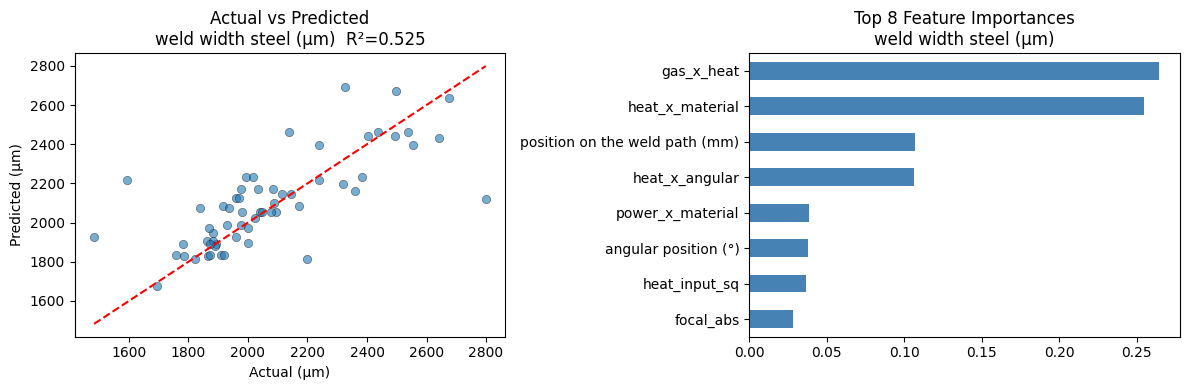


  weld width copper (µm)
    R²  : 0.8753
    MAE : 44.02 µm


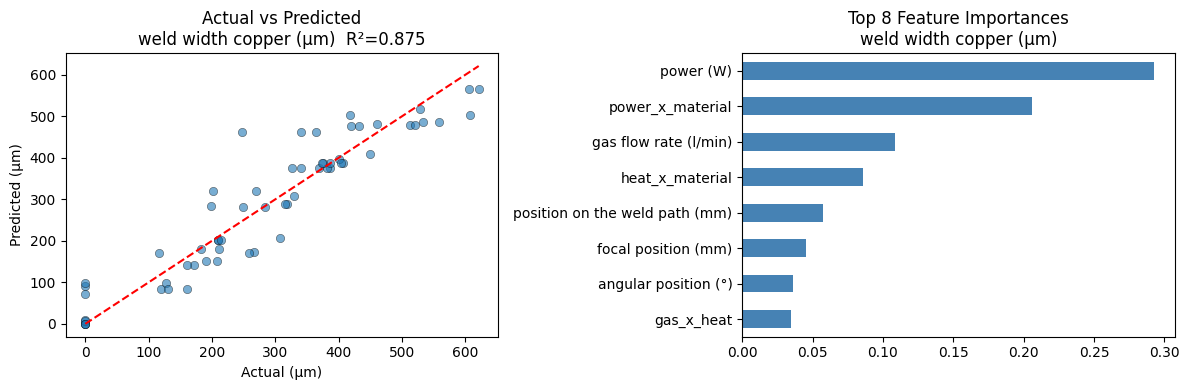


  weld depth copper (µm)
    R²  : 0.7991
    MAE : 41.32 µm


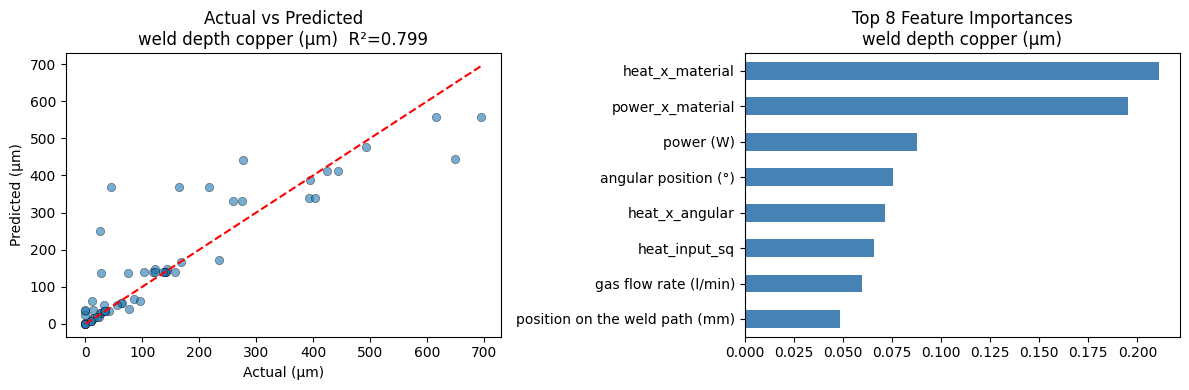


  gap (µm)
    R²  : 0.6939
    MAE : 20.67 µm


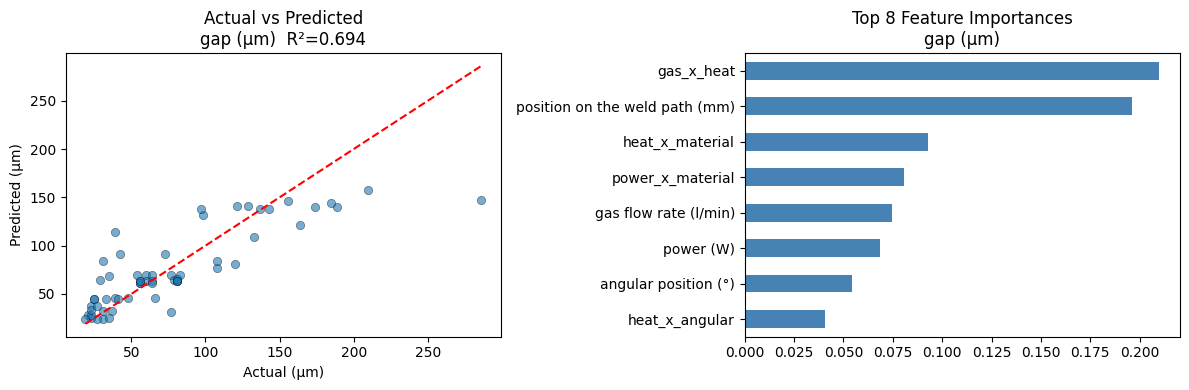

In [ ]:
reg = weld_data_1.dropna(subset=REGRESSION_TARGETS)
reg = reg[reg['weld width steel (µm)'] > 0]  # remove physically impossible zeros

# Best RF params found via RandomizedSearchCV earlier
BEST_REG_PARAMS = {
    'n_estimators': 200, 'min_samples_split': 10,
    'min_samples_leaf': 2, 'max_features': 0.5,
    'max_depth': None, 'bootstrap': True,
    'random_state': 42, 'n_jobs': -1
}

reg_models  = {}
reg_results = {}

print("REGRESSION RESULTS")
print("="*60)

for target in REGRESSION_TARGETS:
    X = reg[FEATURES]
    y = reg[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(**BEST_REG_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    reg_models[target]  = model
    reg_results[target] = {'R2': r2, 'MAE': mae}

    print(f"\n  {target}")
    print(f"    R²  : {r2:.4f}")
    print(f"    MAE : {mae:.2f} µm")

     # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.4)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--')
    axes[0].set_xlabel('Actual (µm)'); axes[0].set_ylabel('Predicted (µm)')
    axes[0].set_title(f'Actual vs Predicted\n{target}  R²={r2:.3f}')

    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values().tail(8)
    fi.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title(f'Top 8 Feature Importances\n{target}')

    plt.tight_layout(); plt.show()





CLASSIFICATION RESULTS — Cracking
  ROC-AUC  : 0.9839
  Threshold: 0.4
              precision    recall  f1-score   support

    No Crack       1.00      0.94      0.97        62
       Crack       0.71      1.00      0.83        10

    accuracy                           0.94        72
   macro avg       0.86      0.97      0.90        72
weighted avg       0.96      0.94      0.95        72



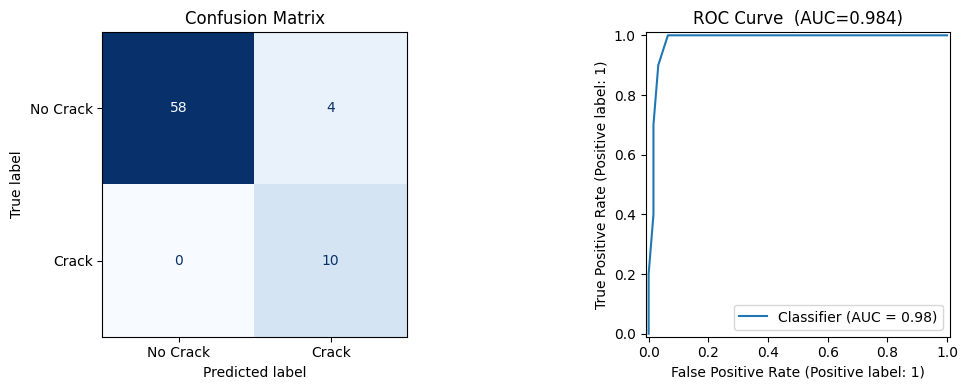

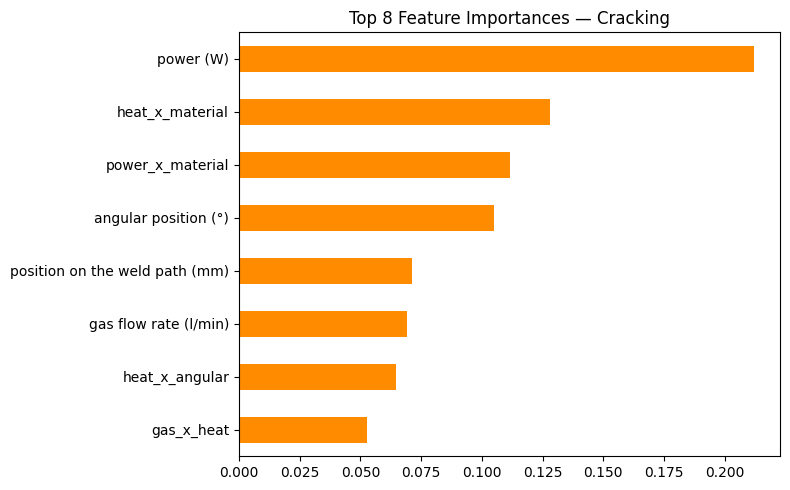

In [ ]:
X_clf = weld_data_1[FEATURES]
y_clf = weld_data_1[CRACK_TARGET]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_model = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=10,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ))
])
clf_model.fit(X_train_c, y_train_c)

y_prob  = clf_model.predict_proba(X_test_c)[:, 1]
y_pred_c = (y_prob >= CRACK_THRESHOLD).astype(int)  # tuned threshold
auc     = roc_auc_score(y_test_c, y_prob)

print("\n\nCLASSIFICATION RESULTS — Cracking")
print("="*60)
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Threshold: {CRACK_THRESHOLD}")
print(classification_report(y_test_c, y_pred_c, target_names=['No Crack','Crack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test_c, y_pred_c)
ConfusionMatrixDisplay(cm, display_labels=['No Crack','Crack']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test_c, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve  (AUC={auc:.3f})')
plt.tight_layout(); plt.show()

fi_clf = pd.Series(
    clf_model.named_steps['clf'].feature_importances_, index=FEATURES
).sort_values().tail(8)
fi_clf.plot(kind='barh', figsize=(8, 5), color='darkorange')
plt.title('Top 8 Feature Importances — Cracking')
plt.tight_layout(); plt.show()

In [ ]:
for target, model in reg_models.items():
    fname = target.replace(' ','_').replace('(','').replace(')','').replace('/','').replace('µ','u')
    joblib.dump(model, f'model_reg_{fname}.pkl')

joblib.dump(clf_model, 'model_clf_cracking.pkl')
print("\n✓ All models saved as .pkl files")


✓ All models saved as .pkl files


In [ ]:
def predict_weld(power, speed, gas_flow, focal_pos, angular_pos,
                 material_thickness, path_position):
    """
    Input your welding parameters, get predictions for all targets.
    """
    row = pd.DataFrame([{
        'power (W)': power,
        'welding speed (m/min)': speed,
        'gas flow rate (l/min)': gas_flow,
        'focal position (mm)': focal_pos,
        'angular position (°)': angular_pos,
        'material strenght steel (mm)': material_thickness,
        'position on the weld path (mm)': path_position
    }])
    row = engineer_features(row)

    print("\n" + "="*50)
    print("WELD PREDICTION")
    print("="*50)
    for target, model in reg_models.items():
        pred = model.predict(row[FEATURES])[0]
        print(f"  {target:<35}: {pred:.1f} µm")

    crack_prob = clf_model.predict_proba(row[FEATURES])[0][1]
    crack_pred = int(crack_prob >= CRACK_THRESHOLD)
    status = "⚠ CRACK LIKELY" if crack_pred else "✓ No Crack"
    print(f"\n  Crack probability : {crack_prob:.1%}")
    print(f"  Crack prediction  : {status}")
    print("="*50)

In [ ]:
predict_weld(
    power=1050, speed=1.0, gas_flow=15,
    focal_pos=0, angular_pos=0,
    material_thickness=0.6, path_position=32
)


WELD PREDICTION
  weld width steel (µm)              : 2022.0 µm
  weld width copper (µm)             : 397.9 µm
  weld depth copper (µm)             : 167.1 µm
  gap (µm)                           : 61.3 µm

  Crack probability : 0.2%
  Crack prediction  : ✓ No Crack


WELD WIDTH STEEL (µm) — actual data distribution
count     298.0
mean     2088.0
std       323.9
min      1191.0
25%      1870.2
50%      2017.0
75%      2256.5
max      3637.0
Name: weld width steel (µm), dtype: float64

WELD WIDTH STEEL — model predictions on full dataset
count     298.0
mean     2094.6
std       258.2
min      1676.9
25%      1901.5
50%      2030.5
75%      2215.2
max      2690.9
dtype: float64

CRACK PROBABILITY — distribution across full dataset
count    360.000
mean       0.168
std        0.357
min        0.000
25%        0.000
50%        0.001
75%        0.006
max        0.999
dtype: float64

Fraction of samples with crack_prob < 0.20 : 81.9%
Fraction of samples with crack_prob < 0.40 : 83.3%
Fraction of samples with crack_prob < 0.60 : 83.3%


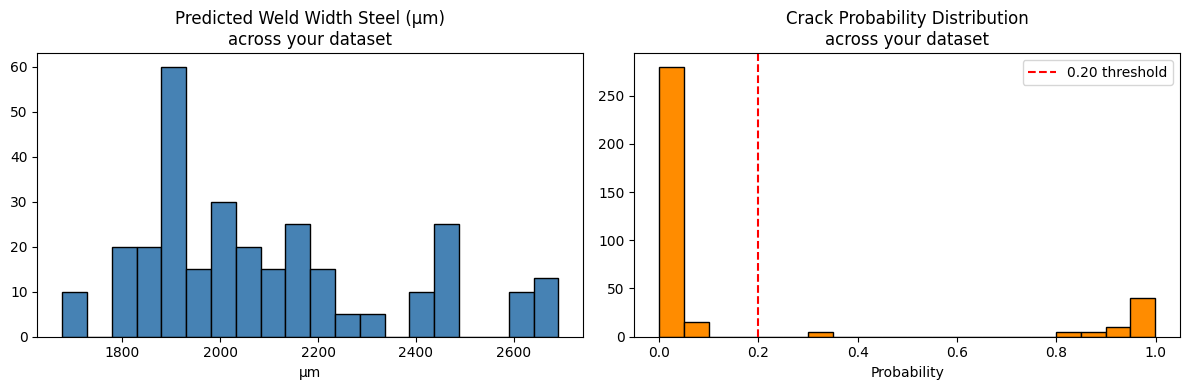


>>> Use the ranges above to set OBJECTIVE constraints.
>>> For weld_width_min/max: use ~10th and 90th percentile of predictions.
>>> For max_crack_prob: pick a value where at least 30–50% of samples qualify.


In [ ]:
# =============================================================================
# RUN THIS FIRST — before optimization
# It tells you realistic values to put in OBJECTIVE
# =============================================================================

# ── 1. What does weld width steel actually look like in your data? ─────────
print("WELD WIDTH STEEL (µm) — actual data distribution")
print(reg['weld width steel (µm)'].describe().round(1))

# ── 2. What does the model predict across your data? ─────────────────────
sample_preds = reg_models['weld width steel (µm)'].predict(reg[FEATURES])
print("\nWELD WIDTH STEEL — model predictions on full dataset")
print(pd.Series(sample_preds).describe().round(1))

# ── 3. What crack probabilities does the classifier output? ──────────────
crack_probs = clf_model.predict_proba(weld_data_1[FEATURES])[:, 1]
print("\nCRACK PROBABILITY — distribution across full dataset")
print(pd.Series(crack_probs).describe().round(3))
print(f"\nFraction of samples with crack_prob < 0.20 : {(crack_probs < 0.20).mean():.1%}")
print(f"Fraction of samples with crack_prob < 0.40 : {(crack_probs < 0.40).mean():.1%}")
print(f"Fraction of samples with crack_prob < 0.60 : {(crack_probs < 0.60).mean():.1%}")

# ── 4. Plot distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample_preds, bins=20, color='steelblue', edgecolor='k')
axes[0].set_title('Predicted Weld Width Steel (µm)\nacross your dataset')
axes[0].set_xlabel('µm')

axes[1].hist(crack_probs, bins=20, color='darkorange', edgecolor='k')
axes[1].axvline(0.20, color='red', linestyle='--', label='0.20 threshold')
axes[1].set_title('Crack Probability Distribution\nacross your dataset')
axes[1].set_xlabel('Probability')
axes[1].legend()

plt.tight_layout(); plt.show()

print("\n>>> Use the ranges above to set OBJECTIVE constraints.")
print(">>> For weld_width_min/max: use ~10th and 90th percentile of predictions.")
print(">>> For max_crack_prob: pick a value where at least 30–50% of samples qualify.")

  0%|          | 0/500 [00:00<?, ?it/s]


✓ Optimization done!  Best score: 299.66 µm

  RECOMMENDED PARAMETER RANGES  (top 20 solutions)
  Objective : maximize  weld depth copper (µm)
  Constraint: crack prob < 20%
  Constraint: weld width steel 1800–2500 µm
                                   Min    Mean     Max
power (W)                       677.76  828.41  874.27
welding speed (m/min)             0.50    0.54    0.63
gas flow rate (l/min)             5.85   20.72   27.24
focal position (mm)              -2.58   -1.31   -0.14
angular position (°)             -3.90    1.69    4.29
material strenght steel (mm)      0.81    0.86    1.04
position on the weld path (mm)   28.20   45.59   57.00

  PREDICTED OUTCOMES AT BEST PARAMETER SET
  weld width steel (µm)              : 2260.8 µm
  weld width copper (µm)             : 88.6 µm
  weld depth copper (µm)             : 299.7 µm
  gap (µm)                           : 103.9 µm
  Crack probability                  : 14.1%  →  ✓ No Crack Expected


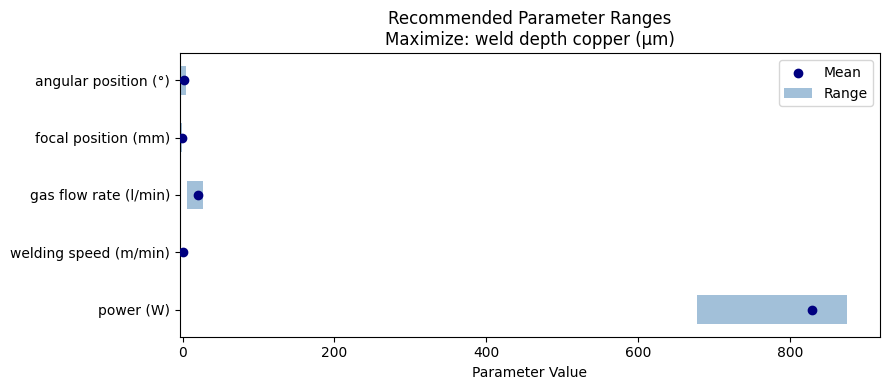

In [ ]:
# =============================================================================
# OPTIMIZATION — paste this at the end of your existing Colab code
# Constraints are now based on your actual data distribution
# =============================================================================

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────────────────────────────────────────
# YOUR OBJECTIVE — change these to suit your engineering goal
# ─────────────────────────────────────────────────────────────────────────────

OBJECTIVE = {
    # 81.9% of your data already has crack_prob < 0.20 — this is a safe threshold
    'max_crack_prob': 0.20,

    # Your predicted weld width ranges from ~1677 to ~2691 µm
    # Using 10th–90th percentile of predictions as a realistic band
    'weld_width_min': 1800,
    'weld_width_max': 2500,

    # What to maximize — pick one:
    #   'weld depth copper (µm)'  → deeper penetration
    #   'weld width copper (µm)'  → wider copper join
    #   'gap (µm)'                → larger gap tolerance
    'maximize': 'weld depth copper (µm)',
}

# ─────────────────────────────────────────────────────────────────────────────
# SEARCH SPACE — bounds from your actual dataset
# ─────────────────────────────────────────────────────────────────────────────

SEARCH_SPACE = {
    'power (W)'                     : (500,  2000),
    'welding speed (m/min)'         : (0.5,  3.0),
    'gas flow rate (l/min)'         : (5,    30),
    'focal position (mm)'           : (-3,   3),
    'angular position (°)'          : (-10,  10),
    'material strenght steel (mm)'  : (0.3,  1.2),
    'position on the weld path (mm)': (0,    60),
}

# ─────────────────────────────────────────────────────────────────────────────
# OPTIMIZER
# ─────────────────────────────────────────────────────────────────────────────

def objective_fn(trial):
    params = {k: trial.suggest_float(k, lo, hi) for k, (lo, hi) in SEARCH_SPACE.items()}

    row = pd.DataFrame([params])
    row = engineer_features(row)

    crack_prob  = clf_model.predict_proba(row[FEATURES])[0][1]
    weld_width  = reg_models['weld width steel (µm)'].predict(row[FEATURES])[0]
    goal_value  = reg_models[OBJECTIVE['maximize']].predict(row[FEATURES])[0]

    # Reject if crack risk too high
    if crack_prob > OBJECTIVE['max_crack_prob']:
        return -1e6

    # Penalise if weld width outside band
    lo_w = OBJECTIVE['weld_width_min']
    hi_w = OBJECTIVE['weld_width_max']
    if not (lo_w <= weld_width <= hi_w):
        return -abs(weld_width - (lo_w + hi_w) / 2)   # distance from centre of band

    return goal_value


study = optuna.create_study(direction='maximize')
study.optimize(objective_fn, n_trials=500, show_progress_bar=True)

print(f"\n✓ Optimization done!  Best score: {study.best_value:.2f} µm")

# ─────────────────────────────────────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────────────────────────────────────

valid_trials = [t for t in study.trials if t.value is not None and t.value > 0]
valid_trials = sorted(valid_trials, key=lambda t: t.value, reverse=True)[:20]

if not valid_trials:
    print("\n⚠ Still no valid trials. Run the relaxed version below.")
else:
    top_df = pd.DataFrame([t.params for t in valid_trials])

    print("\n" + "="*60)
    print(f"  RECOMMENDED PARAMETER RANGES  (top {len(valid_trials)} solutions)")
    print(f"  Objective : maximize  {OBJECTIVE['maximize']}")
    print(f"  Constraint: crack prob < {OBJECTIVE['max_crack_prob']:.0%}")
    print(f"  Constraint: weld width steel {OBJECTIVE['weld_width_min']}–{OBJECTIVE['weld_width_max']} µm")
    print("="*60)
    print(pd.DataFrame({
        'Min' : top_df.min().round(2),
        'Mean': top_df.mean().round(2),
        'Max' : top_df.max().round(2),
    }).to_string())

    # ── Predicted outcomes at the best point ──────────────────────────────
    best_row = pd.DataFrame([study.best_params])
    best_row = engineer_features(best_row)

    print("\n" + "="*60)
    print("  PREDICTED OUTCOMES AT BEST PARAMETER SET")
    print("="*60)
    for target, model in reg_models.items():
        print(f"  {target:<35}: {model.predict(best_row[FEATURES])[0]:.1f} µm")

    crack_p = clf_model.predict_proba(best_row[FEATURES])[0][1]
    print(f"  {'Crack probability':<35}: {crack_p:.1%}  →  {'⚠ CRACK LIKELY' if crack_p >= CRACK_THRESHOLD else '✓ No Crack Expected'}")

    # ── Bar chart of recommended ranges ───────────────────────────────────
    params_to_plot = ['power (W)', 'welding speed (m/min)',
                      'gas flow rate (l/min)', 'focal position (mm)', 'angular position (°)']
    labels = [p for p in params_to_plot if p in top_df.columns]
    mins   = [top_df[p].min()  for p in labels]
    means  = [top_df[p].mean() for p in labels]
    maxs   = [top_df[p].max()  for p in labels]

    fig, ax = plt.subplots(figsize=(9, 4))
    y = np.arange(len(labels))
    ax.barh(y, [mx - mn for mn, mx in zip(mins, maxs)],
            left=mins, height=0.5, color='steelblue', alpha=0.5, label='Range')
    ax.scatter(means, y, color='navy', zorder=5, label='Mean')
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.set_xlabel('Parameter Value')
    ax.set_title(f'Recommended Parameter Ranges\nMaximize: {OBJECTIVE["maximize"]}')
    ax.legend(); plt.tight_layout(); plt.show()


# =============================================================================
# FALLBACK — if still no valid trials, run this relaxed version
# Removes the weld width constraint entirely, only keeps crack constraint
# =============================================================================

if not valid_trials:
    print("\nRunning relaxed optimization (no weld width constraint)...")

    def objective_relaxed(trial):
        params = {k: trial.suggest_float(k, lo, hi) for k, (lo, hi) in SEARCH_SPACE.items()}
        row = pd.DataFrame([params])
        row = engineer_features(row)
        crack_prob = clf_model.predict_proba(row[FEATURES])[0][1]
        if crack_prob > OBJECTIVE['max_crack_prob']:
            return -1e6
        return reg_models[OBJECTIVE['maximize']].predict(row[FEATURES])[0]

    study2 = optuna.create_study(direction='maximize')
    study2.optimize(objective_relaxed, n_trials=500, show_progress_bar=True)

    valid2 = [t for t in study2.trials if t.value is not None and t.value > 0]
    valid2 = sorted(valid2, key=lambda t: t.value, reverse=True)[:20]

    if valid2:
        top2 = pd.DataFrame([t.params for t in valid2])
        print(f"\n✓ Relaxed optimization found {len(valid2)} valid solutions")
        print("\nRECOMMENDED RANGES (crack constraint only):")
        print(pd.DataFrame({'Min': top2.min().round(2),
                            'Mean': top2.mean().round(2),
                            'Max': top2.max().round(2)}).to_string())
    else:
        print("⚠ Even relaxed run found nothing — your max_crack_prob may be too strict.")
        print("  Try setting max_crack_prob to 0.50 and re-run.")

In [ ]:
# =============================================================================
# PASTE THIS AT THE END OF YOUR EXISTING COLAB CODE
# Make sure your reg_models and clf_model are already trained before running this
# =============================================================================

# !pip install optuna   ← run this once in Colab if not installed
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
 # suppress trial-by-trial logs

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — DEFINE YOUR OBJECTIVE
# Change these values based on what YOU want from the weld
# ─────────────────────────────────────────────────────────────────────────────

OBJECTIVE = {
    # Hard constraint: reject any solution where crack probability exceeds this
    'max_crack_prob': 0.25,           # 20% — lower = safer, fewer solutions found

    # Hard constraint: weld width steel must stay in this band (µm)
    'weld_width_min': 350,
    'weld_width_max': 600,

    # What to MAXIMIZE (pick one):
    #   'weld depth copper (µm)'   → deeper penetration
    #   'weld width copper (µm)'   → wider copper join
    #   'gap (µm)'                 → larger gap tolerance
    'maximize': 'weld depth copper (µm)',
}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — DEFINE SEARCH SPACE
# Set realistic bounds for your laser welding machine
# ─────────────────────────────────────────────────────────────────────────────

SEARCH_SPACE = {
    'power (W)'                     : (500,  2000),
    'welding speed (m/min)'         : (0.5,  3.0),
    'gas flow rate (l/min)'         : (5,    30),
    'focal position (mm)'           : (-3,   3),
    'angular position (°)'          : (-10,  10),
    'material strenght steel (mm)'  : (0.3,  1.2),   # usually fixed in practice
    'position on the weld path (mm)': (0,    60),
}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — RUN OPTUNA OPTIMIZER
# Optuna tries 500 combinations, uses your trained models to evaluate each one
# No actual welding — very fast!
# ─────────────────────────────────────────────────────────────────────────────

def objective_fn(trial):
    # Suggest parameter values within bounds
    params = {k: trial.suggest_float(k, lo, hi) for k, (lo, hi) in SEARCH_SPACE.items()}

    row = pd.DataFrame([params])
    row = engineer_features(row)   # same function from your existing code

    # Ask classifier: what's the crack probability?
    crack_prob = clf_model.predict_proba(row[FEATURES])[0][1]

    # Ask regression model: what's the predicted weld width steel?
    weld_width = reg_models['weld width steel (µm)'].predict(row[FEATURES])[0]

    # Ask regression model: what's the value of our goal?
    goal_value = reg_models[OBJECTIVE['maximize']].predict(row[FEATURES])[0]

    # ── Constraints ──────────────────────────────────────────────────────
    # If crack risk too high → reject (return very negative score)
    if crack_prob > OBJECTIVE['max_crack_prob']:
        return -1e6

    # If weld width out of band → penalise proportionally
    if not (OBJECTIVE['weld_width_min'] <= weld_width <= OBJECTIVE['weld_width_max']):
        deviation = min(
            abs(weld_width - OBJECTIVE['weld_width_min']),
            abs(weld_width - OBJECTIVE['weld_width_max'])
        )
        return -deviation

    # All constraints satisfied → return goal value to maximize
    return goal_value


study = optuna.create_study(direction='maximize')
study.optimize(objective_fn, n_trials=500, show_progress_bar=True)

print(f"\n✓ Optimization done! Best score: {study.best_value:.2f} µm")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — SHOW RESULTS
# Take top 20 valid trials and report the range of each parameter
# ─────────────────────────────────────────────────────────────────────────────

# Collect top 20 valid trials (those that satisfied constraints)
valid_trials = [t for t in study.trials if t.value is not None and t.value > 0]
valid_trials = sorted(valid_trials, key=lambda t: t.value, reverse=True)[:20]

if not valid_trials:
    print("\n⚠ No valid trials found. Try relaxing the constraints in OBJECTIVE.")
else:
    top_df = pd.DataFrame([t.params for t in valid_trials])

    print("\n" + "="*60)
    print(f"  RECOMMENDED PARAMETER RANGES  (top {len(valid_trials)} solutions)")
    print(f"  Objective: Maximize {OBJECTIVE['maximize']}")
    print("="*60)

    summary = pd.DataFrame({
        'Min'  : top_df.min().round(2),
        'Mean' : top_df.mean().round(2),
        'Max'  : top_df.max().round(2),
    })
    print(summary.to_string())

    # ── Predicted outcomes at the single best point ───────────────────────
    best_row = pd.DataFrame([study.best_params])
    best_row = engineer_features(best_row)

    print("\n" + "="*60)
    print("  PREDICTED OUTCOMES AT BEST PARAMETER SET")
    print("="*60)
    for target, model in reg_models.items():
        val = model.predict(best_row[FEATURES])[0]
        print(f"  {target:<35}: {val:.1f} µm")

    crack_p = clf_model.predict_proba(best_row[FEATURES])[0][1]
    status  = "⚠  CRACK LIKELY" if crack_p >= CRACK_THRESHOLD else "✓  No Crack Expected"
    print(f"  {'Crack probability':<35}: {crack_p:.1%}  →  {status}")

    # ── Bar chart of recommended ranges ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    params_to_plot = ['power (W)', 'welding speed (m/min)',
                      'gas flow rate (l/min)', 'focal position (mm)',
                      'angular position (°)']
    labels, mins, means, maxs = [], [], [], []
    for p in params_to_plot:
        if p in top_df.columns:
            labels.append(p)
            mins.append(top_df[p].min())
            means.append(top_df[p].mean())
            maxs.append(top_df[p].max())

    y = np.arange(len(labels))
    ax.barh(y, [mx - mn for mn, mx in zip(mins, maxs)],
            left=mins, height=0.5, color='steelblue', alpha=0.5, label='Range (min–max)')
    ax.scatter(means, y, color='navy', zorder=5, label='Mean')
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.set_xlabel('Parameter Value')
    ax.set_title(f'Recommended Parameter Ranges\nObjective: maximize {OBJECTIVE["maximize"]}')
    ax.legend(); plt.tight_layout(); plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]


✓ Optimization done! Best score: -1164.88 µm

⚠ No valid trials found. Try relaxing the constraints in OBJECTIVE.


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.8 MB/s eta 0:00:00
